# EDA Plot

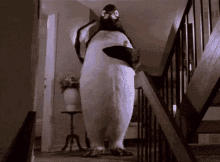

In [67]:
# --- Import all required libraries ---
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from collections import Counter
import pandas as pd
import seaborn as sns
import folium                           # prior: pip install folium and uv add folium
from folium.plugins import HeatMap
print("Libraries ready!")

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"})
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

Libraries ready!


In [8]:
# --- Load the eda dataset ---
df = pd.read_csv("data/eda_clean_final.csv")
print(f"Shape: {df.shape}")
# --- Inspect data types and missing values ---
df.info()
print(type(df["last_sale"][0]))
df.head()

Shape: (21420, 21)
<class 'pandas.DataFrame'>
RangeIndex: 21420 entries, 0 to 21419
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   house_id       21420 non-null  int64  
 1   zip            21420 non-null  int64  
 2   lat            21420 non-null  float64
 3   long           21420 non-null  float64
 4   view_quality   21420 non-null  int64  
 5   waterfront     21420 non-null  int64  
 6   sqft_lot15     21420 non-null  float64
 7   sqft_living15  21420 non-null  float64
 8   sqft_lot       21420 non-null  float64
 9   price          21420 non-null  float64
 10  last_sale      21420 non-null  str    
 11  yr_built       21420 non-null  int64  
 12  yr_renovated   21420 non-null  int64  
 13  grade          21420 non-null  int64  
 14  condition      21420 non-null  int64  
 15  sqft_living    21420 non-null  float64
 16  sqft_basement  21420 non-null  float64
 17  sqft_above     21420 non-null  float64
 18

,house_id,zip,lat,long,view_quality,waterfront,sqft_lot15,sqft_living15,sqft_lot,price,...,yr_built,yr_renovated,grade,condition,sqft_living,sqft_basement,sqft_above,floors,bedrooms,bathrooms
0,1000102,98002,47.326,-122.214,1,0,7316.000,2060.000,9373.000,300000.000,...,1991,1991,7,3,2400.000,0.000,2400.000,2.000,6,3.000
1,1200019,98166,47.444,-122.351,1,0,21891.000,2590.000,26036.000,647500.000,...,1947,1947,8,4,2060.000,900.000,1160.000,1.000,4,1.750
2,1200021,98166,47.443,-122.347,1,0,20023.000,2250.000,43000.000,400000.000,...,1952,1952,7,3,1460.000,0.000,1460.000,1.000,3,1.000
3,2800031,98168,47.478,-122.265,1,0,10320.000,1290.000,7599.000,235000.000,...,1930,1930,6,4,1430.000,420.000,1010.000,1.500,3,1.000
4,3600057,98144,47.580,-122.294,1,0,3504.000,1480.000,3504.000,402500.000,...,1951,2013,7,3,1650.000,890.000,760.000,1.000,4,2.000


In [ ]:
# Heatmap of all houses
m = folium.Map(location=[df["lat"].mean(), df["long"].mean()], zoom_start=12)
heat_data = df[["lat", "long"]].values.tolist()
HeatMap(heat_data).add_to(m)
m

In [ ]:
# KEEP FLOORS COLOR CODED MAP 
df_map = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
].copy()

unique_floors = sorted(df_map["floors"].dropna().unique())
n_colors = len(unique_floors) # if this works, use own colors, same as the regression intersection
custom_colors = ["#F72585", "#AD4EAD", "#2D3AB3", "#527914", "#461306"]



#custom_colors = sns.color_palette("Set2", n_colors).as_hex()
#custom_colors = sns.color_palette("tab10", n_colors).as_hex()
#custom_colors = sns.color_palette("pastel", n_colors).as_hex()
#custom_colors = sns.color_palette("viridis", n_colors).as_hex()
color_map = dict(zip(unique_floors, custom_colors))


if len(custom_colors) < len(unique_floors):
    raise ValueError("Not enough custom colors for the number of floor categories.")

color_map = dict(zip(unique_floors, custom_colors))

m = folium.Map(
    location=[df_map["lat"].mean(), df_map["long"].mean()],
    zoom_start=15
)

for _, row in df_map.iterrows():
    color = color_map.get(row["floors"], "gray")
    
    folium.CircleMarker(
        location=[row["lat"], row["long"]],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"floors: {row['floors']}"
    ).add_to(m)

legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 160px;
    background-color: white;
    border: 2px solid grey;
    z-index: 9999;
    font-size: 14px;
    padding: 10px;
">
<b>Floors</b><br>
"""

for floor, color in color_map.items():
    legend_html += f"""
    <div>
        <span style="
            display:inline-block;
            width:12px;
            height:12px;
            background:{color};
            margin-right:8px;
        "></span>{floor}
    </div>
    """

legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

m


In [5]:
#Heatmap zoomed to area
filtered_folium = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
]
m = folium.Map(location=[filtered_folium["lat"].mean(), filtered_folium["long"].mean()], zoom_start=15
)
heat_data = filtered_folium[["lat", "long"]].values.tolist()
HeatMap(heat_data).add_to(m)
m

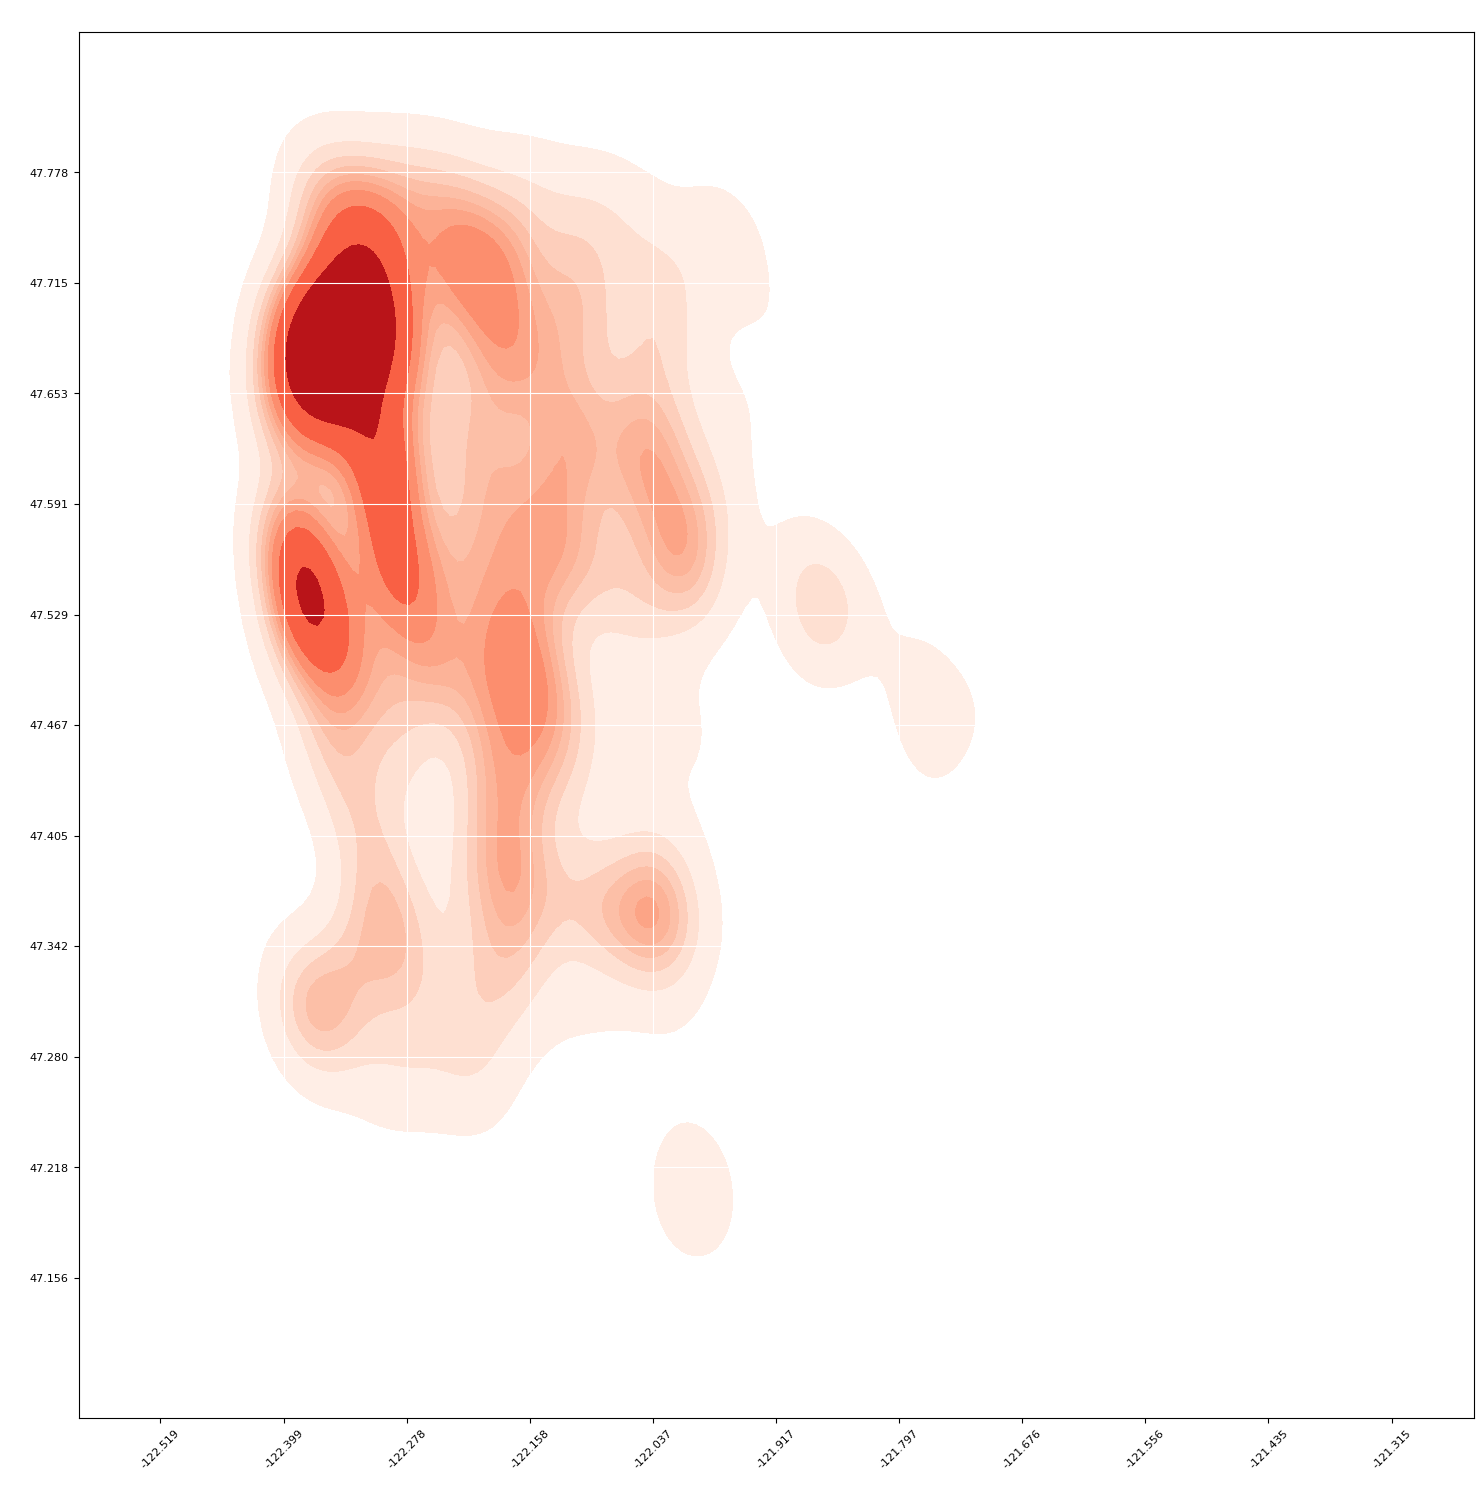

In [16]:
# simpler heatmap
fig, ax = plt.subplots(figsize=(18, 18))
sns.kdeplot(
    data=df,
    x="long",
    y="lat",
    fill=True,
    cmap="Reds",
    ax=ax
)

x_ticks = np.linspace(df["long"].min(), df["long"].max(), 11)
y_ticks = np.linspace(df["lat"].min(), df["lat"].max(), 11)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

#ax.scatter(df["long"], df["lat"], s=12, color="blue", alpha=0.6)

ax.set_xticklabels([f"{x:.3f}" for x in x_ticks], rotation=45, fontsize=8)
ax.set_yticklabels([f"{y:.3f}" for y in y_ticks], fontsize=8)

ax.tick_params(axis="both", which="both", labelbottom=True, labelleft=True)

ax.tick_params(colors="black")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Coordinate Density")

ax.grid(True)
plt.show()


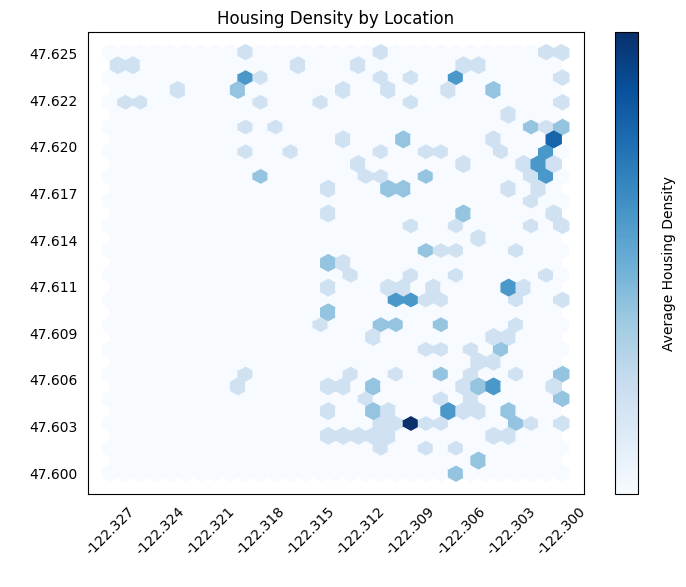

In [ ]:
# map with binned coordinates (just number of sold houses per binned area)
filtered = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
]
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(
    filtered["long"],
    filtered["lat"],
    gridsize=30,
    cmap="Blues"
)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Average Housing Density", color="black")

x_ticks = np.linspace(filtered["long"].min(), filtered["long"].max(), 10)
y_ticks = np.linspace(filtered["lat"].min(), filtered["lat"].max(), 10)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels([f"{x:.3f}" for x in x_ticks], rotation=45, color="black")
ax.set_yticklabels([f"{y:.3f}" for y in y_ticks], color="black")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Housing Density by Location", color="black")

plt.show()

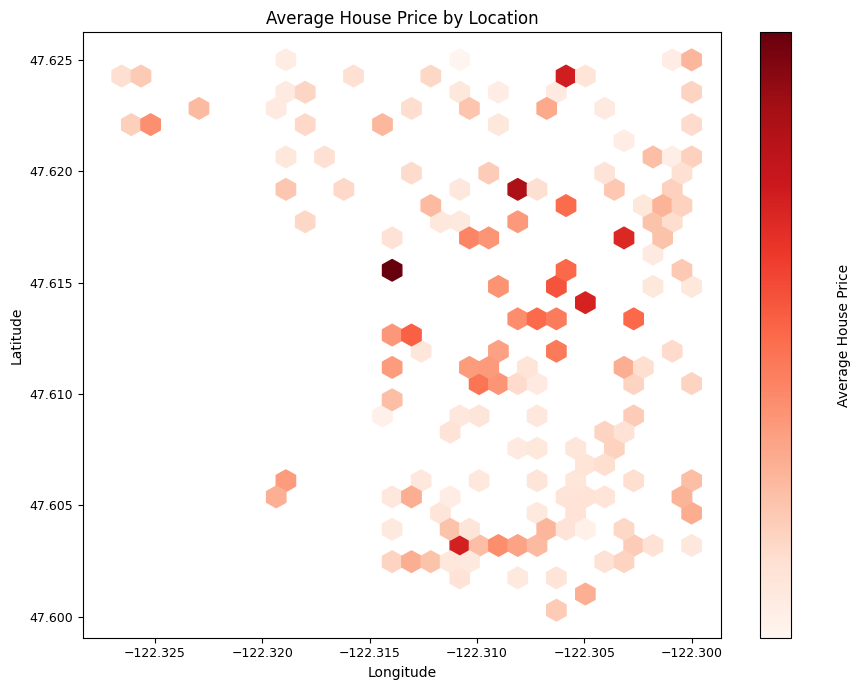

In [ ]:
# Average House Price by binned area
filtered = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
]
fig, ax = plt.subplots(figsize=(9, 7))

hb = ax.hexbin(
    filtered["long"],
    filtered["lat"],
    C=df["price"],
    reduce_C_function=np.mean,
    gridsize=30,
    cmap="Reds"
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Average House Price", color="black")

ax.set_xlabel("Longitude", color="black")
ax.set_ylabel("Latitude", color="black")
ax.set_title("Average House Price by Location", color="black")

ax.tick_params(axis="both", colors="black", labelsize=9)

for spine in ax.spines.values():
    spine.set_color("black")

plt.tight_layout()
plt.show()


In [56]:
# RUN FILTERED and test floors series
filtered = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
]

unique_floors = sorted(filtered["floors"].unique())
print(unique_floors)

print(filtered["sqft_living15"].median())
print(filtered["sqft_living"].median())
print(filtered["sqft_living"].mean())
print(filtered["sqft_living"].min(), filtered["sqft_living"].max())

[np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0)]
1510.0
1550.0
1646.4685990338164
550.0 4000.0


Mean: 577566.1980676329
Median: 549000.0
Mode: 500000.0
Min: 169317.0
Max: 1260000.0
Variance: 32214860618.577084
Standard deviation: 179484.9871676656


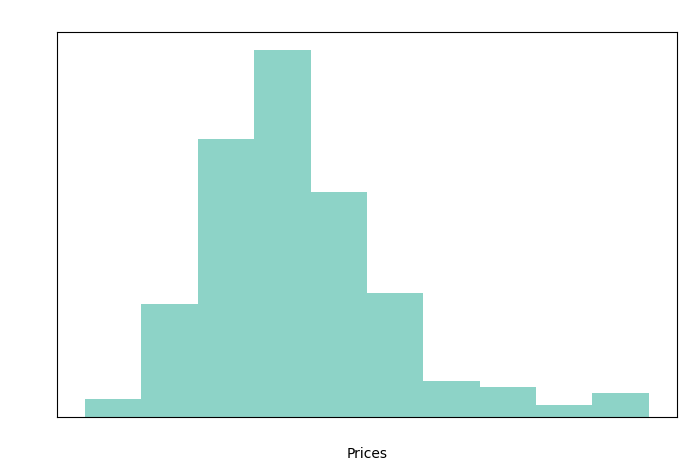

In [ ]:
# early look at raw prices in the area
print("Mean:", filtered["price"].mean())
print("Median:", filtered["price"].median())
print("Mode:", filtered["price"].mode()[0])
print("Min:", filtered["price"].min())
print("Max:", filtered["price"].max())
print("Variance:", filtered["price"].var())
print("Standard deviation:", filtered["price"].std())

filtered["price"].plot(kind="hist", title="Distribution prices")
plt.xlabel("Prices", color="black")
plt.show()

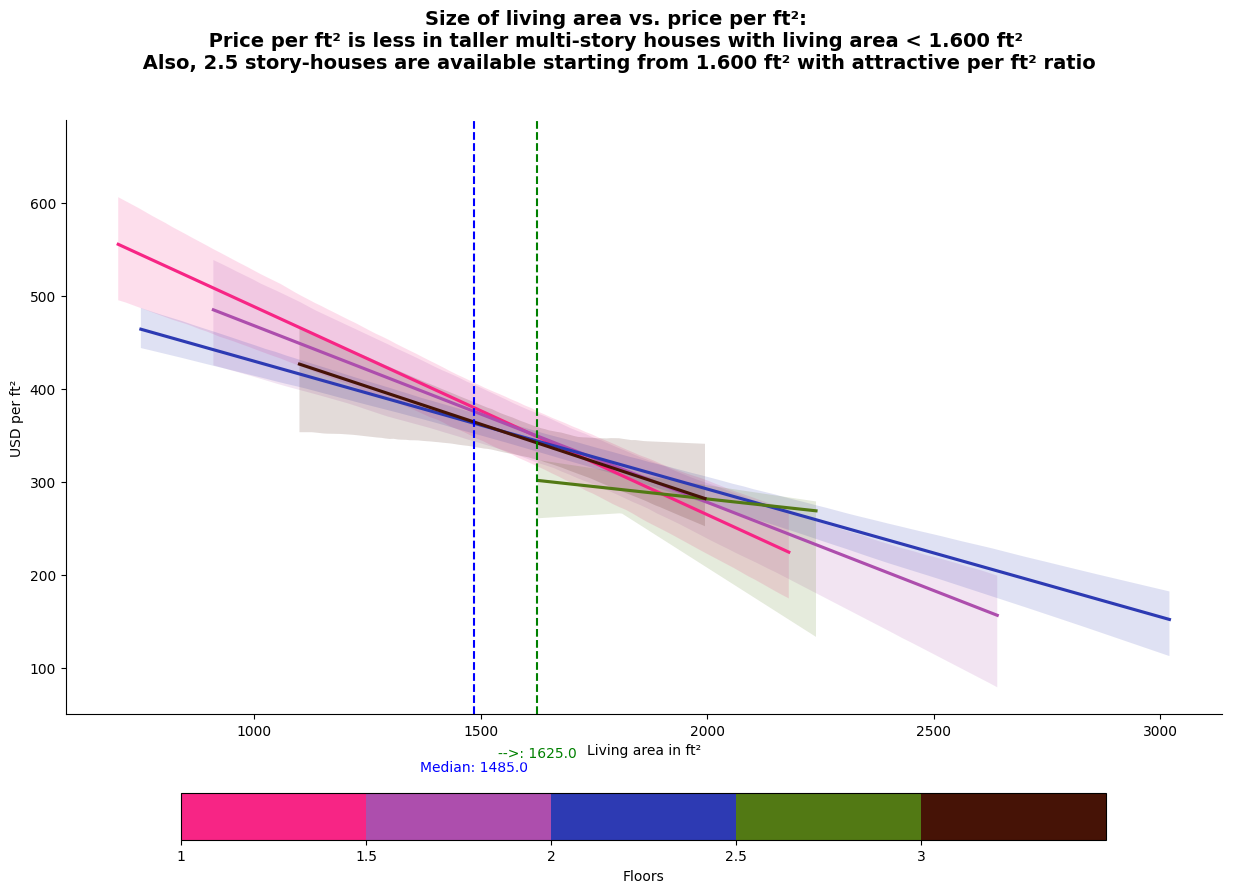

In [ ]:
# KEEP: Price distributions by sqft_living hued by nr of floors

# y axis - price per ft²
filtered = filtered.copy()
filtered = filtered[filtered["sqft_living"] > 0]
filtered["price_per_sqft"] = filtered["price"] / filtered["sqft_living"]

# Calculate x_median as the median of sqft_living values: main intersection
x_median = filtered["sqft_living"].median()

# Calculate x_observation as the observed shifted intersection (visual “center”) especially with skewed housing data
x_observation = filtered["sqft_living"].median()+140


# Get unique floor values for the colorbar ticks
unique_floors = sorted(filtered["floors"].unique())

# Create a colormap from your custom colors
custom_colors = ["#F72585", "#AD4EAD", "#2D3AB3", "#527914", "#461306"]
cmap = ListedColormap(custom_colors)

# lmplot: scatter WITH a regression line per floors 
price_distribution = sns.lmplot(
    data=filtered,
    x="sqft_living",
    y="price_per_sqft",
    hue="floors",
    #scatter=False,
    scatter_kws={"alpha": 0.0, "s": 9},
    height=9,
    aspect=1.3,
    palette=custom_colors)


# Add vertical line at x_median
axvline = price_distribution.ax.axvline(x=x_median, color='blue', linestyle='--', linewidth=1.5)
# Create a visible label with contrasting colors
label = axvline.get_label()
price_distribution.ax.annotate(
    f'Median: {x_median:.1f} sqft',
    xy=(x_median, 0), xycoords='data',
    xytext=(0, 20), textcoords='offset points',
    ha='center', color='red',  # Use contrasting color
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

# Add label x_median
price_distribution.ax.text(x_median, 0.95, f'Median: {x_median:.1f}', 
                          ha='center', va='top', color='blue', 
                          fontsize=10,
                          bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))


# Add vertical line at x_observation
axvline = price_distribution.ax.axvline(x=x_observation, color='green', linestyle='--', linewidth=1.5)
# Create a visible label with contrasting colors
label = axvline.get_label()
price_distribution.ax.annotate(
    f'Median: {x_observation:.1f} sqft',
    xy=(x_observation, 0), xycoords='data',
    xytext=(0, 20), textcoords='offset points',
    ha='center', color='red',  # Use contrasting color
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

# Add label x_observation
price_distribution.ax.text(x_observation, 0.95, f'-->: {x_observation:.1f}', 
                          ha='center', va='bottom', color='green', 
                          fontsize=10,
                          bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.1'))


# Create boundaries for the colorbar (between each unique value)
boundaries = np.append(unique_floors, unique_floors[-1] + 1) if len(unique_floors) > 0 else [0, 1]
norm = BoundaryNorm(boundaries, cmap.N)

# Create a scalar mappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add horizontal colorbar
cbar = price_distribution.figure.colorbar(sm, ax=price_distribution.ax, 
                                      orientation='horizontal',
                                      pad=0.1,    # Padding to separate from plot
                                      shrink=0.8) # Adjust size for better fit
cbar.set_label('Floors', color='black')
cbar.set_ticks(unique_floors)
cbar.set_ticklabels([str(int(f)) if f.is_integer() else str(f) for f in unique_floors])
cbar.ax.tick_params(colors='black')

# Set axis labels and ticks 
price_distribution.set_axis_labels('Living area in ft²', 'USD per ft²', color="black")
price_distribution.ax.tick_params(colors='black')

plt.suptitle("Size of living area vs. price per ft²:\n Price per ft² is less in taller multi-story houses with living area < 1.600 ft² \n Also, 2.5 story-houses are available starting from 1.600 ft² with attractive per ft² ratio", fontsize=14, fontweight="bold", y=1.02, color="black")
plt.tight_layout()
plt.show()


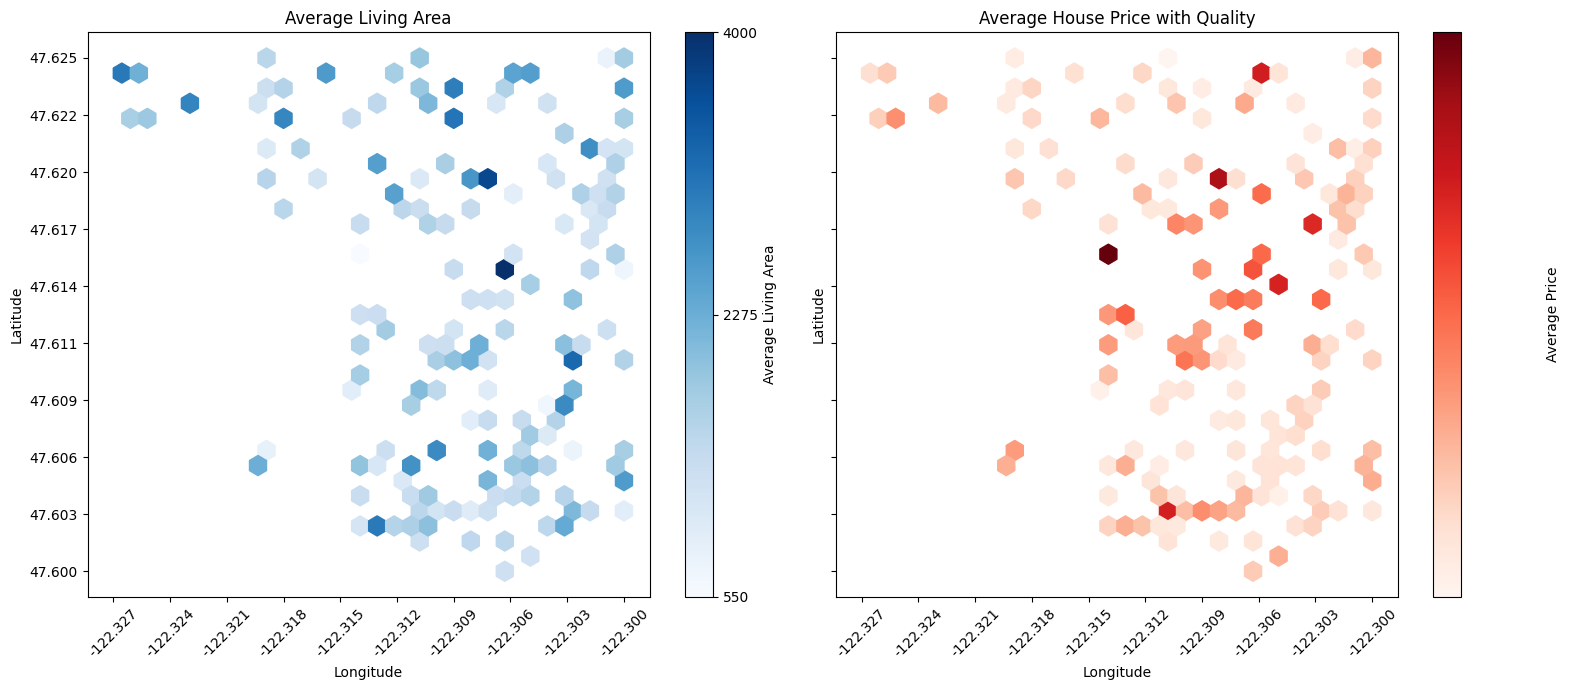

In [ ]:
# REWORK, not done! side by side: Average House Density & Average House Price
filtered = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Left: density

hb1 = axes[0].hexbin(
    filtered["long"],
    filtered["lat"],
    C=filtered["sqft_living"],
    reduce_C_function=np.mean,
    gridsize=30,
    #mincnt=1,
    cmap="Blues"
    )

cb1 = fig.colorbar(hb1, ax=axes[0])
cb1.set_label("Average Living Area", color="black")
cb1.ax.tick_params(colors='black')

dens_min = hb1.get_array().min()
dens_max = hb1.get_array().max()
dens_ticks = np.linspace(dens_min, dens_max, 3)
cb1.set_ticks(dens_ticks)
cb1.set_ticklabels([f"{x:.0f}" for x in dens_ticks])

axes[0].set_title("Average Living Area", color="black")
axes[0].set_xlabel("Longitude", color="black")
axes[0].set_ylabel("Latitude", color="black")

# Right: average price
hb2 = axes[1].hexbin(
    filtered["long"],
    filtered["lat"],
    C=df["price"],
    reduce_C_function=np.mean,
    gridsize=30,
    cmap="Reds",
    mincnt=1
)
cb2 = fig.colorbar(hb2, ax=axes[1])
cb2.set_label("Average Price", color="black")

price_min = np.nanmin(hb2.get_array())
price_max = np.nanmax(hb2.get_array())
price_ticks = np.linspace(price_min, price_max, 3)
cb2.set_ticks(price_ticks)
cb2.set_ticklabels([f"{x:,.0f}" for x in price_ticks])

axes[1].set_title("Average House Price with Quality", color="black")
axes[1].set_xlabel("Longitude", color="black")
axes[1].set_ylabel("Latitude", color="black")

# Shared axis ticks
x_ticks = np.linspace(filtered["long"].min(), filtered["long"].max(), 10)
y_ticks = np.linspace(filtered["lat"].min(), filtered["lat"].max(), 10)

for ax in axes:
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_xticklabels([f"{x:.3f}" for x in x_ticks], rotation=45, color="black")
    ax.set_yticklabels([f"{y:.3f}" for y in y_ticks], color="black")
    ax.tick_params(axis="both", colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")

plt.tight_layout()
plt.show()


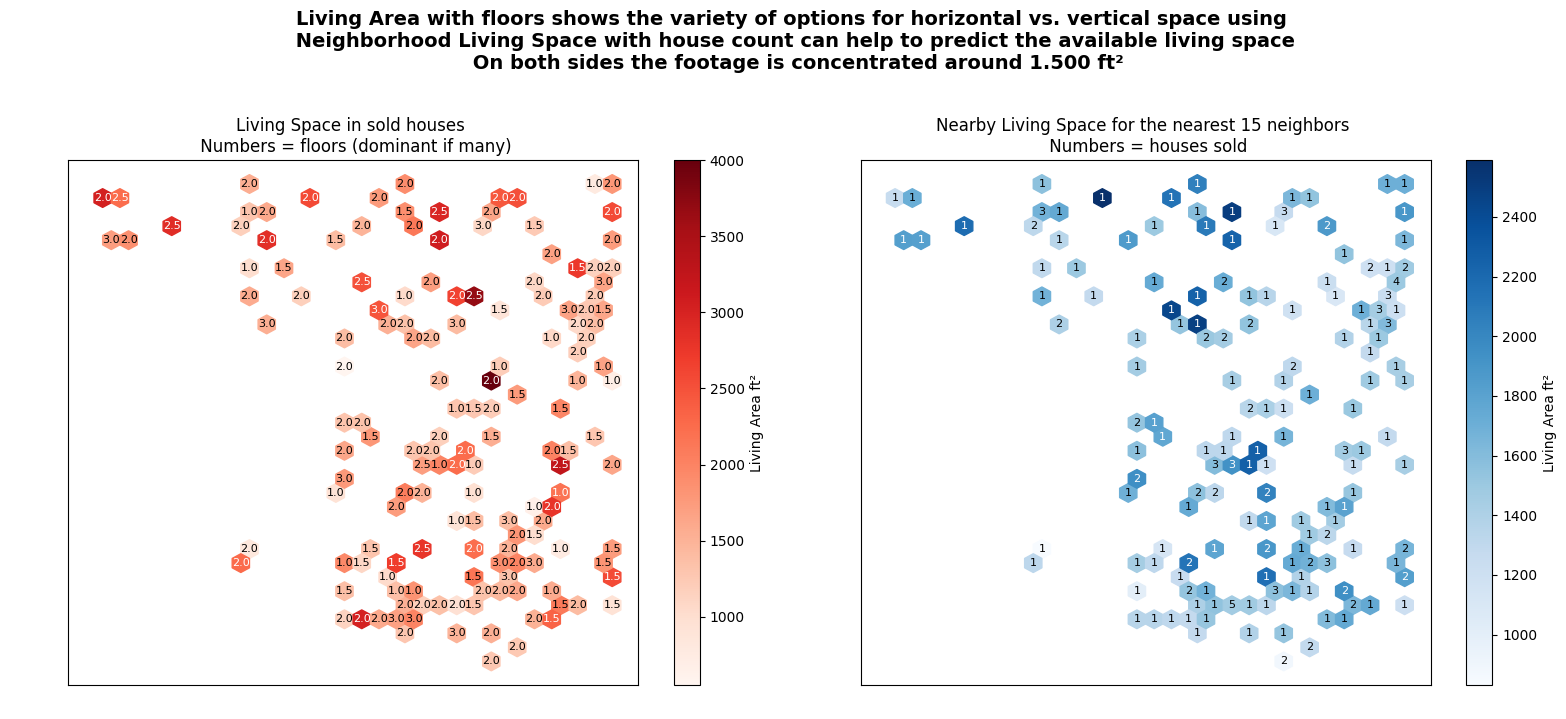

In [57]:
# KEEP Side by side Living space with floors vs. Neighborhood Living Space with house count

filtered = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
].copy()

gridsize = 30
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

points = filtered[["long", "lat"]].to_numpy()
floors = filtered["floors"].to_numpy()

def text_color_from_hexbin(hb, i, cmap_name="Reds"):
    cmap = plt.get_cmap(cmap_name)
    norm = hb.norm
    val = hb.get_array()[i]
    r, g, b, _ = cmap(norm(val))
    brightness = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if brightness < 0.6 else "black"

# -------- Left plot: avg sqft_living + dominant floors --------
hb1 = axes[0].hexbin(
    filtered["long"],
    filtered["lat"],
    C=filtered["sqft_living"],
    reduce_C_function=np.mean,
    gridsize=gridsize,
    cmap="Reds",
    mincnt=1
)

cb1 = fig.colorbar(hb1, ax=axes[0])
cb1.set_label("Living Area ft²", color="black")
cb1.ax.tick_params(colors="black")

#axes[0].set_xlabel("Longitude", color="black")
#axes[0].set_ylabel("Latitude", color="black")
axes[0].set_title("Living Space in sold houses \n Numbers = floors (dominant if many)", color="black")
#axes[0].tick_params(axis="both", colors="black", labelsize=9)

for spine in axes[0].spines.values():
    spine.set_color("black")

hex_centers1 = hb1.get_offsets()

distances1 = (
    (points[:, None, 0] - hex_centers1[None, :, 0]) ** 2 +
    (points[:, None, 1] - hex_centers1[None, :, 1]) ** 2
)
nearest_hex_idx1 = np.argmin(distances1, axis=1)

hex_floor_map = {}
for point_idx, hex_idx in enumerate(nearest_hex_idx1):
    hex_floor_map.setdefault(hex_idx, []).append(floors[point_idx])

for hex_idx, floor_vals in hex_floor_map.items():
    dominant_floor = Counter(floor_vals).most_common(1)[0][0]
    xh, yh = hex_centers1[hex_idx]

    axes[0].text(
        xh, yh, str(dominant_floor),
        ha="center", va="center",
        fontsize=8,
        #fontweight="bold",
        color=text_color_from_hexbin(hb1, hex_idx, "Reds")
        
    )

# -------- Right plot: avg sqft_living15 + count --------
hb2 = axes[1].hexbin(
    filtered["long"],
    filtered["lat"],
    C=filtered["sqft_living15"],
    reduce_C_function=np.mean,
    gridsize=gridsize,
    cmap="Blues",
    mincnt=1
)

cb2 = fig.colorbar(hb2, ax=axes[1])
cb2.set_label("Living Area ft²", color="black")
cb2.ax.tick_params(colors="black")

#axes[1].set_xlabel("Longitude", color="black")
#axes[1].set_ylabel("Latitude", color="black")
axes[1].set_title("Nearby Living Space for the nearest 15 neighbors \n Numbers = houses sold", color="black")
#axes[1].tick_params(axis="both", colors="black", labelsize=9)

for spine in axes[1].spines.values():
    spine.set_color("black")

hex_centers2 = hb2.get_offsets()

distances2 = (
    (points[:, None, 0] - hex_centers2[None, :, 0]) ** 2 +
    (points[:, None, 1] - hex_centers2[None, :, 1]) ** 2
)
nearest_hex_idx2 = np.argmin(distances2, axis=1)

hex_count_map = Counter(nearest_hex_idx2)

for hex_idx, count in hex_count_map.items():
    xh, yh = hex_centers2[hex_idx]

    axes[1].text(
        xh, yh, str(count),
        ha="center", va="center",
        fontsize=8,
        #fontweight="bold",
        color=text_color_from_hexbin(hb2, hex_idx, "Blues")
        
    )
plt.suptitle("Living Area with floors shows the variety of options for horizontal vs. vertical space using \n Neighborhood Living Space with house count can help to predict the available living space \n On both sides the footage is concentrated around 1.500 ft²", fontsize=14, fontweight="bold", y=1.02, color="black")
plt.tight_layout()
plt.show()


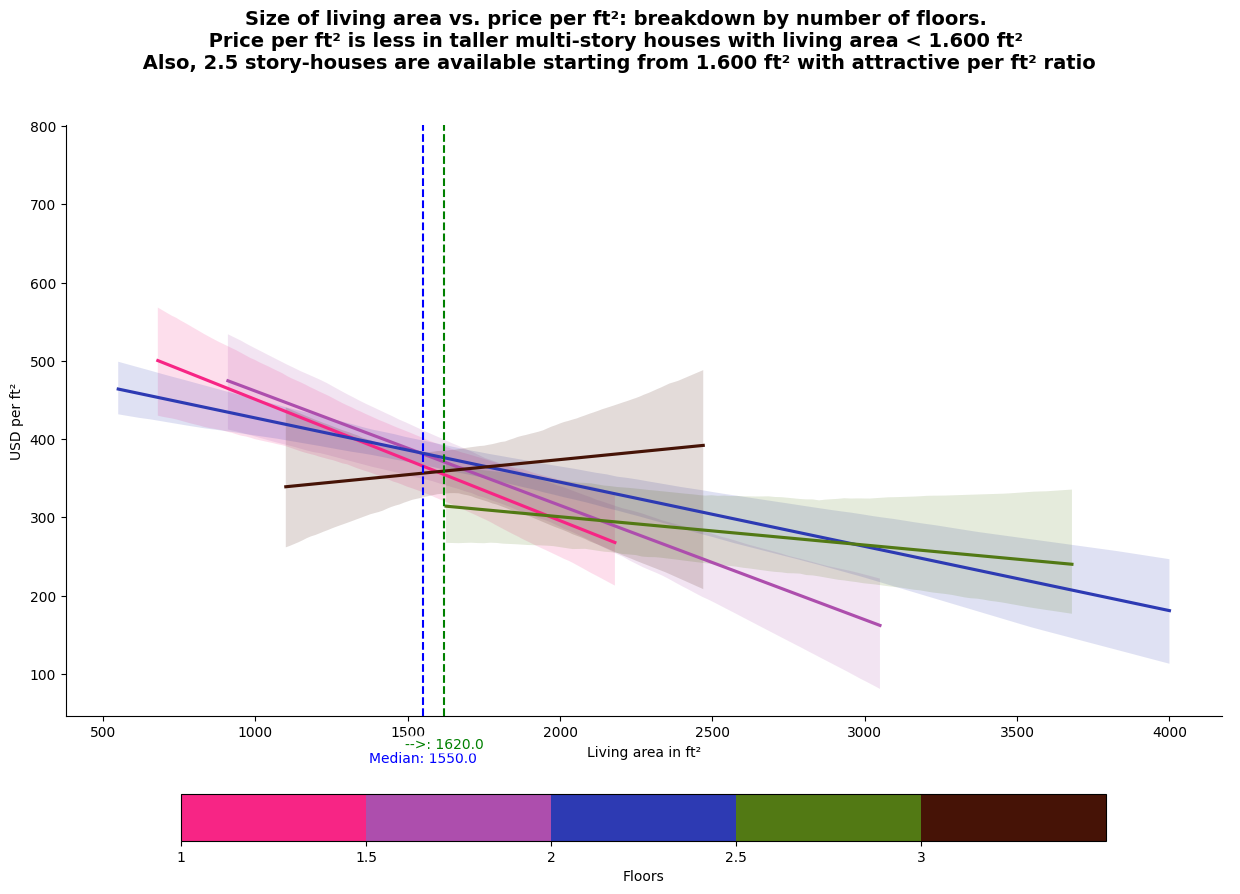

In [ ]:
# Analyse NON-filtered by area price per ft² depending on the property size (living area).

# y axis - price per ft²
filtered = filtered.copy()
filtered = filtered[filtered["sqft_living"] > 0]
filtered["price_per_sqft"] = filtered["price"] / filtered["sqft_living"]

# Calculate x_median as the median of sqft_living values: main intersection
x_median = filtered["sqft_living"].median()

# Calculate x_observation as the observed shifted intersection (visual “center”) especially with skewed housing data
x_observation = filtered["sqft_living"].median()+70


# Get unique floor values for the colorbar ticks
unique_floors = sorted(filtered["floors"].unique())

# Create a colormap from your custom colors
custom_colors = ["#F72585", "#AD4EAD", "#2D3AB3", "#527914", "#461306"]
cmap = ListedColormap(custom_colors)

# lmplot: scatter WITH a regression line per floors 
price_distribution = sns.lmplot(
    data=filtered,
    x="sqft_living",
    y="price_per_sqft",
    hue="floors",
    #scatter=False,
    scatter_kws={"alpha": 0.0, "s": 9},
    height=9,
    aspect=1.3,
    palette=custom_colors)


# Add vertical line at x_median
axvline = price_distribution.ax.axvline(x=x_median, color='blue', linestyle='--', linewidth=1.5)

# Add label x_median
price_distribution.ax.text(x_median, 0.95, f'Median: {x_median:.1f}', 
                          ha='center', va='top', color='blue', 
                          fontsize=10,
                          bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))


# Add vertical line at x_observation
axvline = price_distribution.ax.axvline(x=x_observation, color='green', linestyle='--', linewidth=1.5)

# Add label x_observation
price_distribution.ax.text(x_observation, 0.95, f'-->: {x_observation:.1f}', 
                          ha='center', va='bottom', color='green', 
                          fontsize=10,
                          bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.1'))


# Create boundaries for the colorbar (between each unique value)
boundaries = np.append(unique_floors, unique_floors[-1] + 1) if len(unique_floors) > 0 else [0, 1]
norm = BoundaryNorm(boundaries, cmap.N)

# Create a scalar mappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add horizontal colorbar
cbar = price_distribution.figure.colorbar(sm, ax=price_distribution.ax, 
                                      orientation='horizontal',
                                      pad=0.1,    # Padding to separate from plot
                                      shrink=0.8) # Adjust size for better fit
cbar.set_label('Floors', color='black')
cbar.set_ticks(unique_floors)
cbar.set_ticklabels([str(int(f)) if f.is_integer() else str(f) for f in unique_floors])
cbar.ax.tick_params(colors='black')

# Set axis labels and ticks 
price_distribution.set_axis_labels('Living area in ft²', 'USD per ft²', color="black")
price_distribution.ax.tick_params(colors='black')

plt.suptitle("Size of living area vs. price per ft²: breakdown by number of floors.\n Price per ft² is less in taller multi-story houses with living area < 1.600 ft² \n Also, 2.5 story-houses are available starting from 1.600 ft² with attractive per ft² ratio", fontsize=14, fontweight="bold", y=1.02, color="black")
plt.tight_layout()
plt.show()


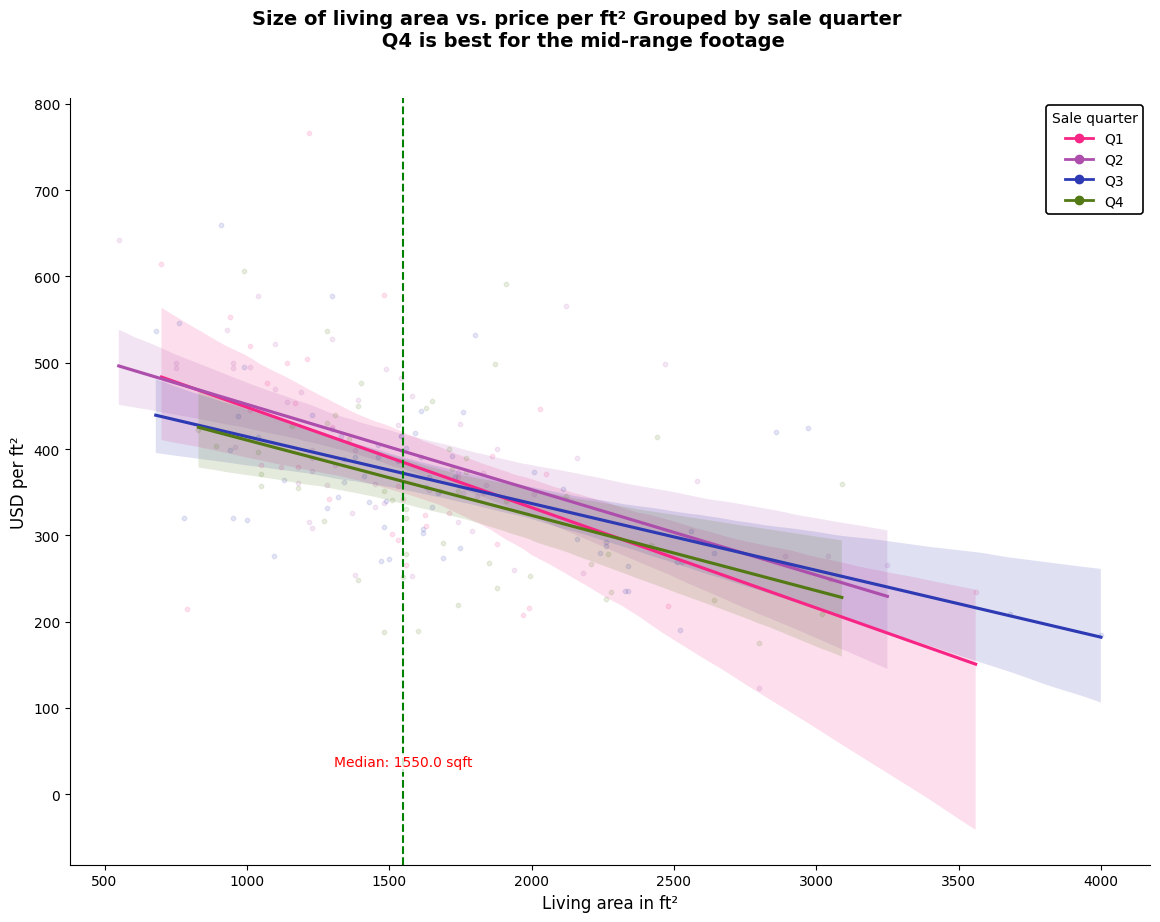

In [ ]:
# KEEP Breakdown prices by season "Q1", "Q2", "Q3", "Q4"

filtered = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
].copy()

filtered = filtered[filtered["sqft_living"] > 0].copy()
filtered["price_per_sqft"] = filtered["price"] / filtered["sqft_living"]

filtered["last_sale"] = pd.to_datetime(filtered["last_sale"], errors="coerce")
filtered["sales_binned"] = "Q" + filtered["last_sale"].dt.quarter.astype("Int64").astype(str)

filtered = filtered[filtered["sales_binned"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()

filtered["sales_binned"] = pd.Categorical(
    filtered["sales_binned"],
    categories=["Q1", "Q2", "Q3", "Q4"],
    ordered=True
)

# Calculate q_observation just a manual visual shifted from median
q_observation = filtered["sqft_living"].median()#+140


quarter_colors = {
    "Q1": "#F72585",
    "Q2": "#AD4EAD",
    "Q3": "#2D3AB3",
    "Q4": "#527914"
}

price_distribution = sns.lmplot(
    data=filtered,
    x="sqft_living",
    y="price_per_sqft",
    hue="sales_binned",
    scatter_kws={"alpha": 0.12, "s": 10},
    height=9,
    aspect=1.3,
    palette=quarter_colors,
    legend=False
)

ax = price_distribution.ax

ax.set_xlabel("Living area in ft²", color="black", fontsize=12)
ax.set_ylabel("USD per ft²", color="black", fontsize=12)
ax.tick_params(axis="both", colors="black")

for spine in ax.spines.values():
    spine.set_color("black")

legend_handles = [
    Line2D(
        [0], [0],
        color=quarter_colors[q],
        marker="o",
        linestyle="-",
        markersize=6,
        linewidth=2,
        label=q
    )
    for q in ["Q1", "Q2", "Q3", "Q4"]
]

legend = ax.legend(
    handles=legend_handles,
    title="Sale quarter",
    loc="best",
    frameon=True
)

legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_alpha(1)

legend.get_title().set_color("black")
for text in legend.get_texts():
    text.set_color("black")

# Add vertical line at q_observation
axvline = price_distribution.ax.axvline(x=q_observation, color='green', linestyle='--', linewidth=1.5)
# Create a visible label with contrasting colors
label = axvline.get_label()
price_distribution.ax.annotate(
    f'Median: {q_observation:.1f} sqft',
    xy=(q_observation, 0), xycoords='data',
    xytext=(0, 20), textcoords='offset points',
    ha='center', color='red',  # Use contrasting color
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

plt.suptitle(
    "Size of living area vs. price per ft² Grouped by sale quarter \n Q4 is best for the mid-range footage",
    fontsize=14,
    fontweight="bold",
    y=1.02,
    color="black"
)

plt.tight_layout()
plt.show()
